# **Quantified Self : An Excursion in Goal Setting**
## Introduction

On January first, 2026, I set myself 11 goals for the year. These goals ranged across all facets of my life, with 6 of them being long term goals that I would revisit at year's end, while the other 5 would be tracked daily. Some goals are dedicated to physical health, challenging myself to run more often and do pushups before bed, while others are dedicated to learning, such as reading more books and learning a new language.

Following April's recent conclusion, we are officially a fourth of the way through the year. In this project, we will be conducting Exploratory Data Analysis on the 5 daily goals I set for myself to determine if I am still holding myself accountable to them. These five goals are:
- Deleting Instagram and Social Media
- Doing daily Duolingo
- Flossing nightly
- Running 600 miles in the year
- Doing pushups before bed

Later on, we will apply classification machine learning algorithms to determine how my performance looks on a daily basis.

The primary stakeholder is myself, as I stand to gain the most from this process, but secondary stakeholders include my parents who will recieve this presentation at the end of this year, as well as classmates who can hopefully glean insight from my experience with long-term and short-term goalsetting.

Without further ado, let's get into the dataset. Data was recorded by hand nightly in the spreadsheet below:

<img src='spreadsheet_snapshot.png' alt='SpreadsheetView'> 

The data was then loaded into a csv file of form:

<img src='habits_csv_snapshot.png' width = 600 height = 300>

For further analysis, I downloaded my instagram usage data from the last year to monitor that goal. I was interested in finding out how much time I spent on Instagram from before I deleted it versus after. Although Instagram doesn't show you a comprehensive hours spent on the app, I chose to use the amount of posts that I liked as a good indicator of how much time I was spending. Just in the last year, I had liked over 4,000 posts, and Instagram has the data for all of them.

So, my 'Liked Posts' JSON data was added and eventually merged with my original dataset.

### Attributes

The data has the following attributes:
- Date (Index)
- Instagram Banished (Int):  1 = No Instagram or social media usage that day, 0 = Any Instagram or social media usage that day
- Miles Ran (Float): Distance in miles ran that day
- Pushups (Int): Pushups completed that day
- Duolingo (Int): 1 = Completed daily Duolingo lesson, 0 = Did not complete daily Duolingo lesson
- Floss (Int): 1 = Flossed teeth that day, 0 = Did not floss teeth that day
- Liked Posts (Int): How many instagram posts I liked that day
- Day of the week

Data is recorded manually every night before I go to bed. Data ranged from January First to April 22nd for 112 instances of data. 

## Data Cleaning

Let's load our data from our csv files and perform any data cleaning we need to do:

In [77]:
import pandas as pd
import utilities as utilities
import matplotlib.pyplot as plt

habits_df = pd.read_csv('habits.csv')
insta_df = utilities.clean_and_load_insta()

### Habits Cleaning

The habits dataframe posed only one main problem: Days where I did not run or do pushups were stored as NaN values, which is not ideal for data analysis. So, a simple fix was to fill those rows with zeroes using;
```python
.fillna(0)
```
for our 'Miles Ran' and 'Pushups' columns. The function below also sets 'Date' to be the index for the data. 

In [78]:
clean_habits_df = utilities.clean_habits(habits_df)

### Instagram Cleaning

The instagram dataframe did not require much data cleaning either, although it was important to ensure that the dates were being loaded the same way. Data from the liked_posts json file was being stored as a timestamp, so using the following loop we:
- Extract the timestamp data from the json file
- Convert the timestamp to a m/d/y format
- Append it to a dict of each day and the amount of liked posts per day
```python
for item in range(len(json_obj)):
        timestamp = json_obj[item]['timestamp']
        day_name = datetime.fromtimestamp(timestamp).strftime('%m/%d/%y')
        daily_groups.setdefault(day_name, []).append(timestamp)

counts_dict = {day: len(items) for day, items in daily_groups.items()}
```

This resulting dictionary is then turned into a dataframe object.

Next, we will need to merge our habits dataframe with the instagram dataframe. Both dataframes have the attribute 'Date', so we are able to perform an outer join on that attribute, being careful to make sure the dates are being stored the same way. The 'is weekend' column is added for later machine learning. We will also fill any NaN values in the liked posts column with zeroes.

In [79]:
clean_habits_df = utilities.clean_habits(habits_df)
clean_habits_df.index = pd.to_datetime(clean_habits_df.index,format='%m/%d/%y').strftime('%m/%d/%y')

merged_df = pd.merge(clean_habits_df,insta_df,left_index=True,right_on='Date',how='outer')
merged_df['Date']= pd.to_datetime(merged_df['Date'],format='%m/%d/%y')
merged_df.set_index('Date',inplace=True)
merged_df['is_weekend'] = (merged_df.index.dayofweek >=5).astype(int)
merged_df['Liked Posts'] = merged_df['Liked Posts'].fillna(0)
merged_df.to_csv('final_df.csv')

print(merged_df.head(5))

            Instagram Banished  Miles Ran  Pushups  Duolingo  Flossed  \
Date                                                                    
2026-01-01                 1.0       4.47     35.0       0.0      1.0   
2026-01-02                 1.0       0.00     35.0       1.0      1.0   
2026-01-03                 1.0       0.00     35.0       1.0      1.0   
2026-01-04                 0.0       0.00     35.0       1.0      1.0   
2026-01-05                 1.0       0.00      0.0       1.0      0.0   

           Day of the Week  Liked Posts  is_weekend  
Date                                                 
2026-01-01        Thursday          0.0           0  
2026-01-02          Friday          0.0           0  
2026-01-03        Saturday          0.0           1  
2026-01-04          Sunday          1.0           1  
2026-01-05          Monday          0.0           0  


Now we have our final dataframe!

### Challenges
The main challenge faced with loading, cleaning, and merging the Dataframes was making sure the 'Date' attributes were handled correctly. I was stuck on figuring out how to merge the tables for a long time, until I realized that one table was storing dates as a Datetime object, while the other was storing them as strings. Once that issue was resolved, merging the tables was complete.

## Data Analysis

One of the main things I am curious about is what our data looks like on each day of the week. So, let's group by day and see what patterns emerge:

In [80]:
grouped_by_dotw = clean_habits_df.groupby('Day of the Week')

weekend_df = pd.concat([grouped_by_dotw.get_group('Friday'),grouped_by_dotw.get_group('Saturday')])
weekday_df = pd.concat([grouped_by_dotw.get_group('Monday'),grouped_by_dotw.get_group('Tuesday'),grouped_by_dotw.get_group('Wednesday'),grouped_by_dotw.get_group('Thursday'),grouped_by_dotw.get_group('Friday')])

print(grouped_by_dotw.sum('Flossed'))

                 Instagram Banished  Miles Ran  Pushups  Duolingo  Flossed
Day of the Week                                                           
Friday                           11      35.03    144.0        15       10
Monday                           13      14.68    250.0        14        9
Saturday                         11     118.06     70.0        12        6
Sunday                            8      18.22    241.0        16       11
Thursday                         14      59.99    291.0        15       10
Tuesday                          12      58.99    330.0        15       13
Wednesday                        15      86.05    285.0        16       11


In [81]:
print(grouped_by_dotw.max('Flossed'))

                 Instagram Banished  Miles Ran  Pushups  Duolingo  Flossed
Day of the Week                                                           
Friday                            1      15.00     39.0         1        1
Monday                            1       7.16     80.0         1        1
Saturday                          1      19.00     35.0         1        1
Sunday                            1      14.75     36.0         1        1
Thursday                          1       8.00     41.0         1        1
Tuesday                           1       8.18     80.0         1        1
Wednesday                         1       8.40     80.0         1        1


Here are the main patterns I am curious about:
- How my instagram usage changed over time
- How my pushups goal performed over time
- Whether or not I floss more on weekends than weekdays
- To what extent I stick to some goals more than others

### Instagram

Instagram doesn't have a great way to see hours spent on the app, so we are using 'Amount of Posts Liked' as an indicator for how often I was on Instagram. 

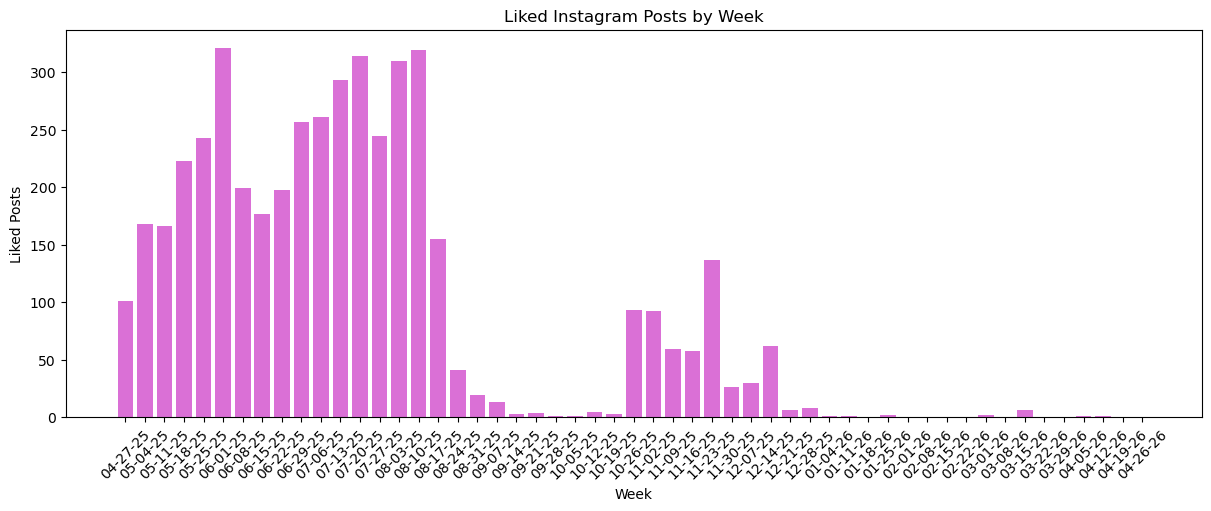

In [82]:
utilities.make_insta_graph(merged_df)

From the graph, you can certainly tell when I had more time to kill during the summer months, as well as towards the end of first semester when classes were a little easier. Once Janury first hit, we see the likes drop off completely, which is a good indicator that I have been sticking well to my goal of staying off Instagram.

### Flossing

One experiment I was curious about was whether or not I flossed more on weekends versus weekdays. From personal experience, it feels like I always get caught up in the hubbub on weekends and forget to floss, but let's see if this is actually the case or not. Note: I do my flossing at night, so Friday and Satuday will be two the days of the week classified as 'the weekend' since they preceed a normal weekend day (Saturday and Sunday).

We will be conducting a two-tailed difference of two proportions test. Since this wasn't a test we covered in class, the formula is included below. 

$\begin{equation} \frac{\hat{p}_{1}-\hat{p}_2}{\sqrt{\hat{p}(1-\hat{p})(\frac{1}{n_{1}}+\frac{1}{n_{2}})}}              \end{equation}$
Where:
-  $\hat{p}_1$ is the proportion of weekdays that I flossed
- $\hat{p}_2$ is the proportion of weekends that I flossed.
- $\hat{p}$ is the pooled proportion of both groups combined.

Using our 5 Step Hypothesis Testing Process:
1. Declare Null and Alternative Hypothesis:
- $H_{0}: \hat{p}_1 = \hat{p}_2$
- $H_{A}: \hat{p}_1 \neq \hat{p}_2$
2. Declare Level of Significance:
- We will use a .10 level of significance.
3. Compute Test Statistic:
- We will compute this below:

In [83]:
from statsmodels.stats.proportion import proportions_ztest

weekday, weekend = utilities.flossing_hyp_test(merged_df)

Test Statistic: -1.597
PValue: 0.110


3. (cont.)
- So, our test statistic is -1.597
4. (and 5); Formulate Decision Rule and Draw Conclusions
- Combining our steps 4 and 5, since our pvalue of .11 was greater than our declared significance level of .10, we do not have significant evidence to reject our null hypothesis that $\hat{p}_1 =\hat{p}_2$. Although there is reasonable evidence to suggest I do not floss as much on weekends, it is not enough to be statistically significant. 

The following program creates a pie chart to represent the weekday and weekend flossing proportions.

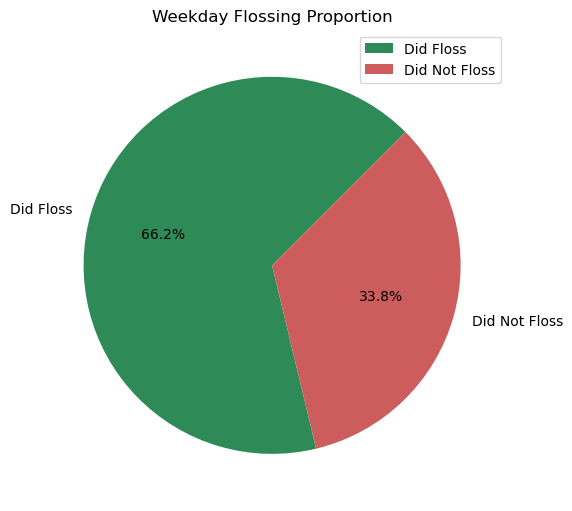

In [84]:
utilities.pie_flossing(weekday,'Weekday')

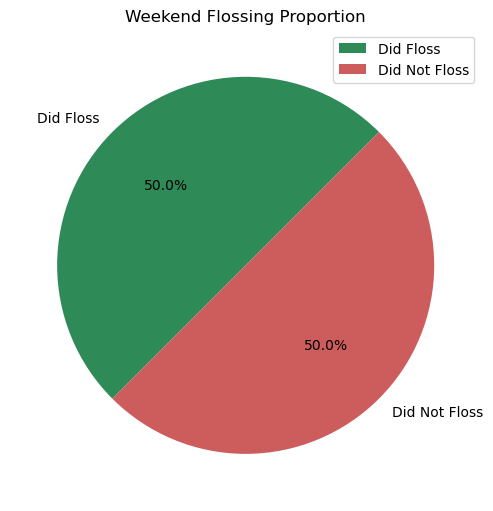

In [85]:
utilities.pie_flossing(weekend,'Weekend')

#### Takeaway:
Although the difference wasn't enough to be statistically significant, I can still definitely be better about flossing on weekends.

### Pushups

As the weeks went on, my New Year's motivation started to wane. Let's look at how the goal of doing pushups performed over the 4 months:

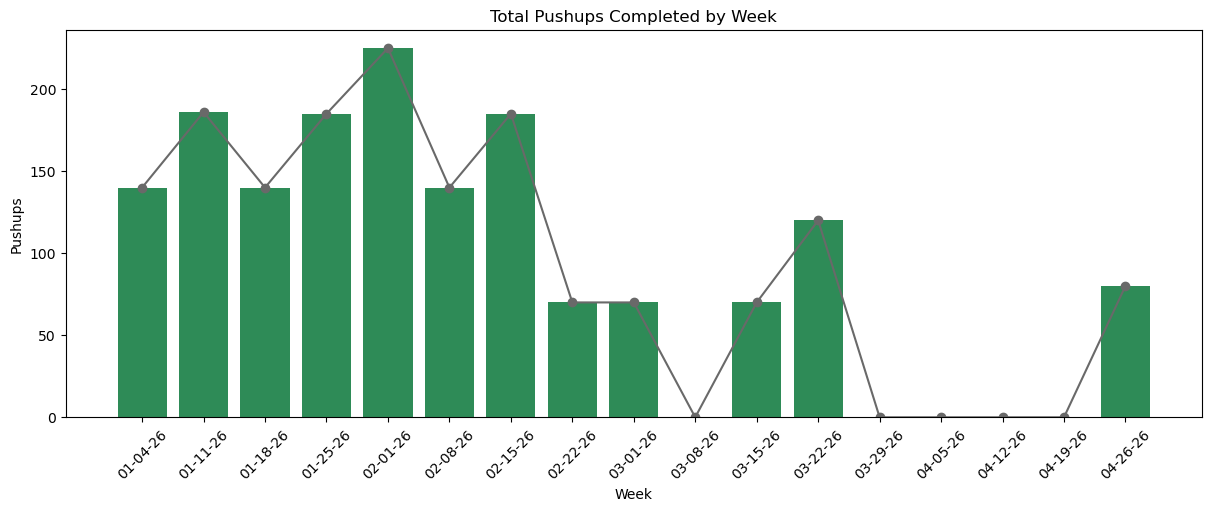

In [86]:
utilities.pushups_display_weeks(merged_df)

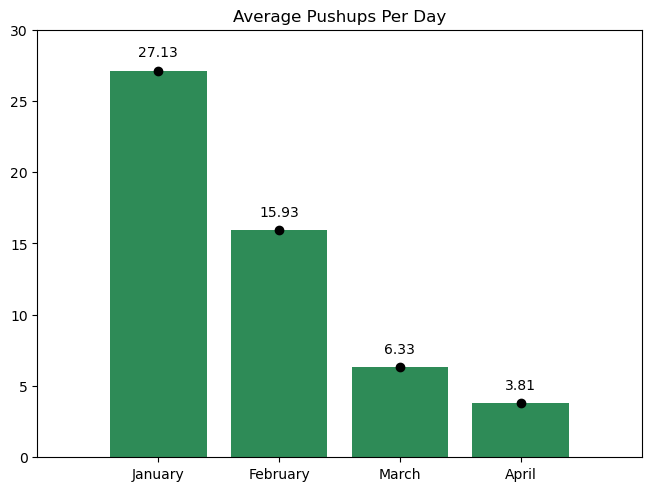

In [87]:
utilities.pushups_display_months(merged_df)

Yikes, it looks like this goal hasn't fared quite as well. Although the data appears to indicate such, let's compute a hypothesis test to determine whether the average pushups by month variance was signifcant or not. 

We will be using an ANOVA hypothesis tests, which is used to determine whether the means of two or more groups differ significantly. The formula for ANOVA is:
$\begin{equation} \frac{MSB}{MSE} \end{equation}$
Where:
- MSB = Mean squares between groups
- MSE = Mean squares within groups

So, our null and alternative hypotheses are:
- $H_{0}: \mu_1 = \mu_2 = \mu_3 = \mu_4 $
- $H_{A}:$ At least one $\mu$ differs significantly

We will use a .05 level of significance.

In [88]:
utilities.pushups_f_test(merged_df)

F Statistic: 8.8303
P-Value: 0.0000


Since our P-value was less than our declared $\alpha$ value, we have significant evidence to reject our null hypothesis that all four groups have the same mean. There is strong evidence to suggest at least one groups differs, which makes sense with our initial observations of the data. 

## Machine Learning

We are curious about the question of whether or not we can predict what day of the week it is based on my habits. I predict the model will be able to do this with some degree of accuracy since some of my habits follow certain patterns:
- I go for long runs on Saturdays, medium runs on Wednesdays, and short runs on Tuesdays and Thursdays
- On Monday, Friday, and Saturday, I do not run.
- On weekends I am more likely to forget to floss or complete daily Duolingo

However, predicting a day of the week is difficult, since there is essentially a 1/7 shot. Also, the rest of my habits can more sporadic, so it could be difficult to glean any sort of pattern. So, any accuracy higher than $1/7 = .1428$% is pretty good. 

In [89]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix,ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier

tree, y_test, y_preds = utilities.decision_tree_dotw(merged_df)

Model Accuracy: 0.36


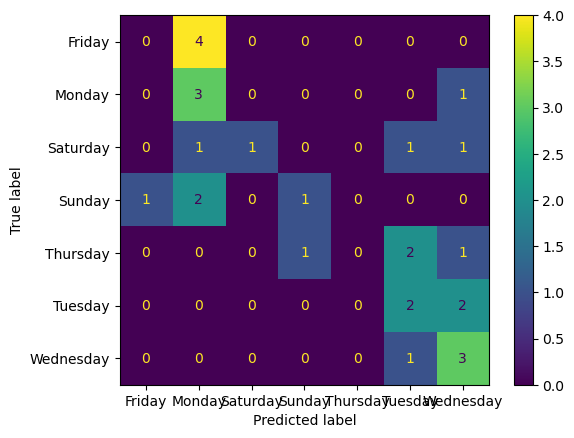

In [90]:
utilities.confusion_matrix_disp(tree,y_test,y_preds)

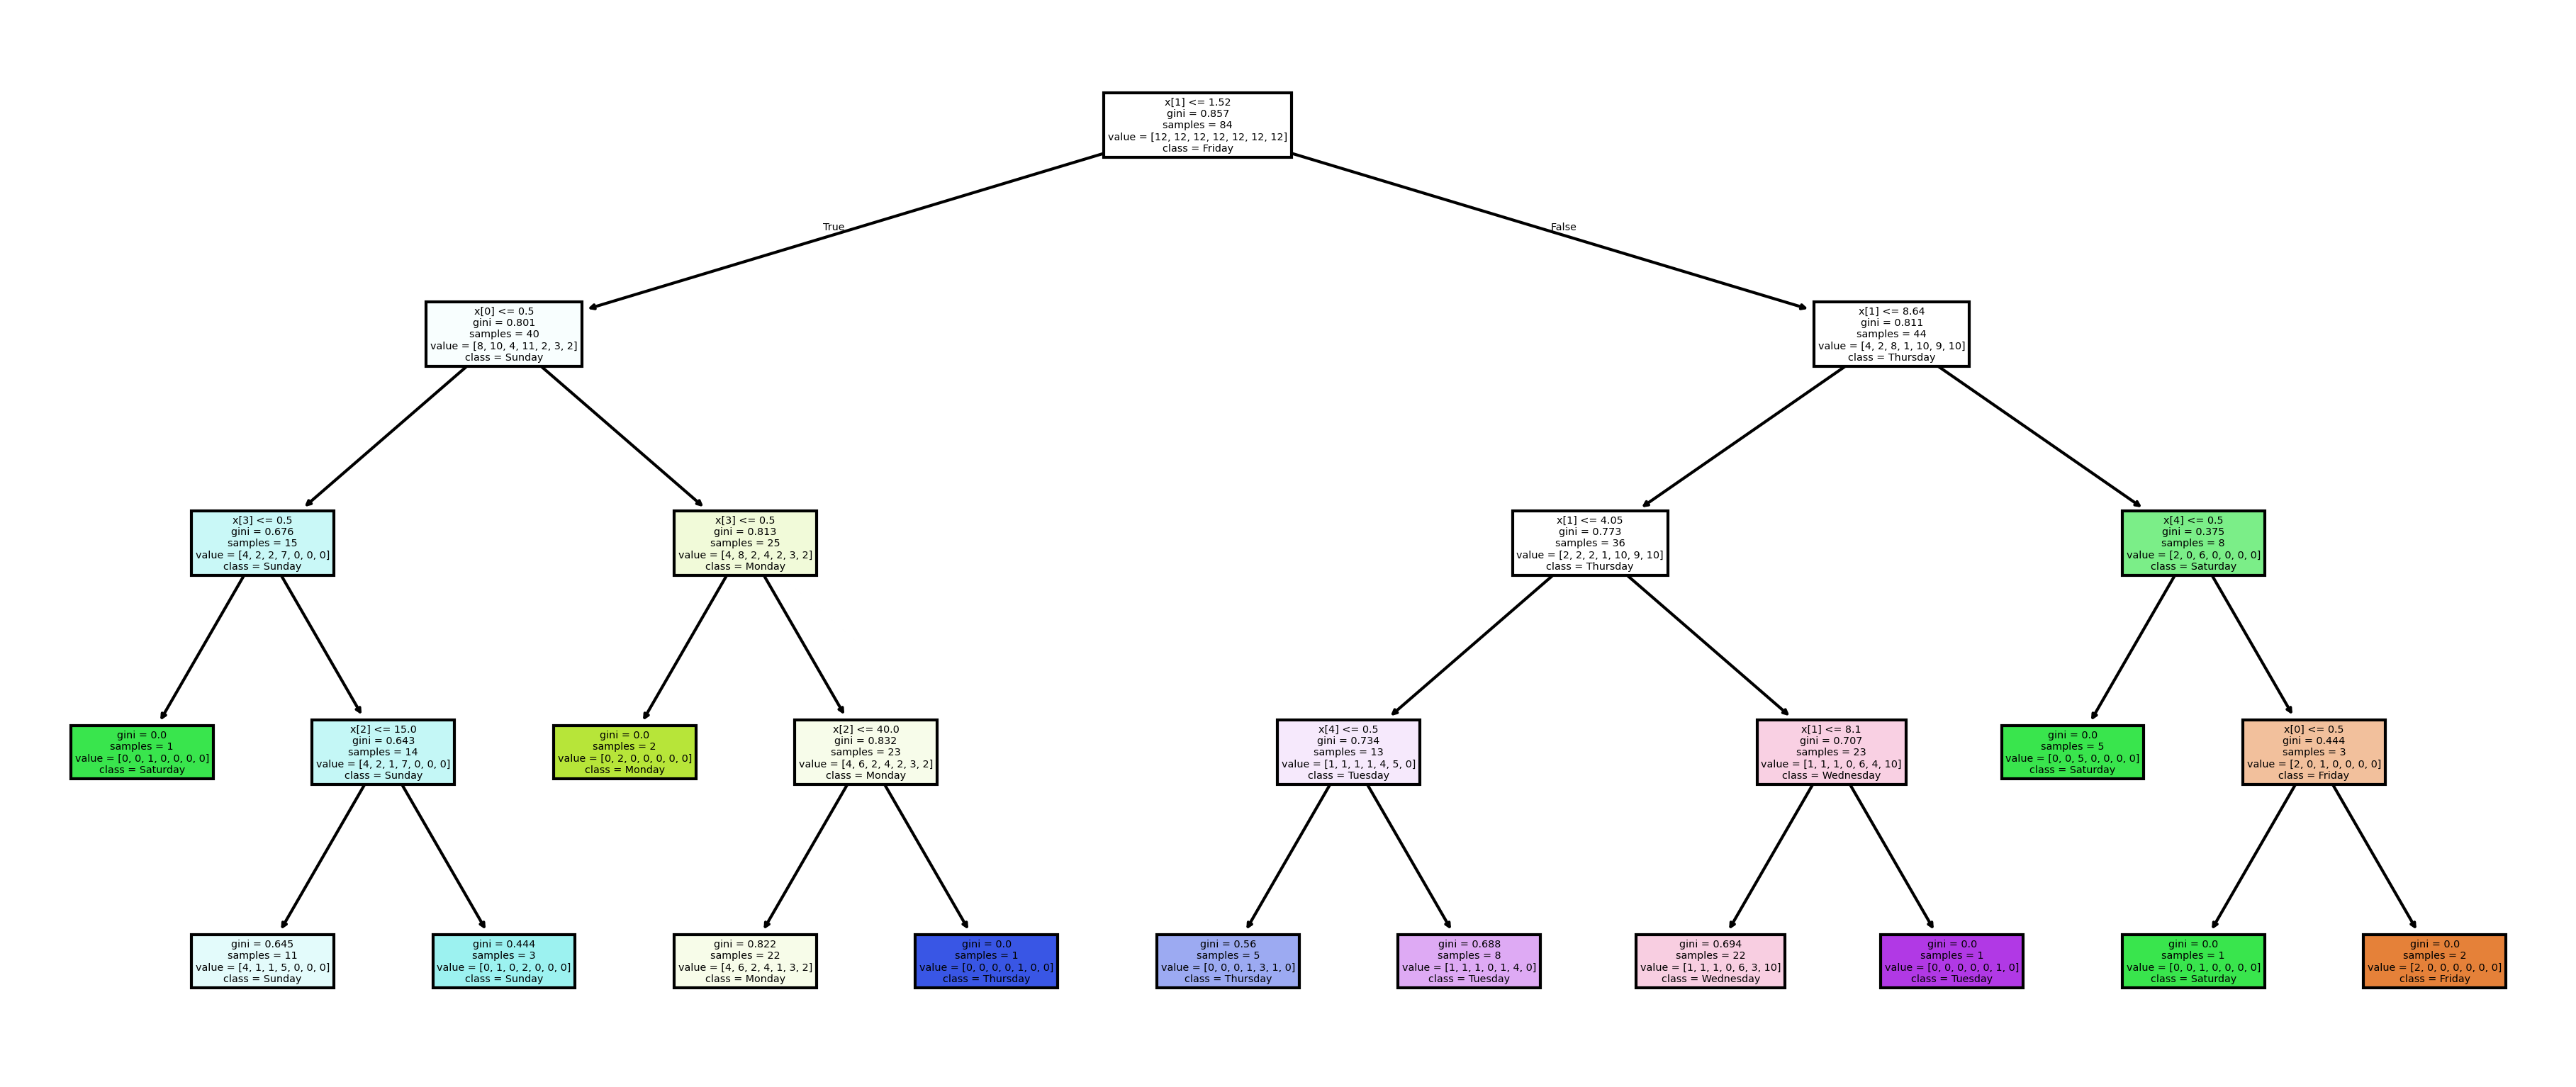

In [91]:
utilities.decision_tree_disp(tree)

The model reached a maximum accuracy of $46$%, with an average accuracy around $25-35%$%. Although this score isn't incredible, it is still decently higher than the baseline, so I would say this is an acceptable result!

Next, let's try something similar but simplify the model to predicting whether or not it is the weekend. We will use the is_weekend column we previously added as the attribute to predict. Since weekdays make up $5/7$ of the week, we should expect a baseline of $5/7$ or $71.42$%. I predict this task will be easier for the model since it no longer has to distinguish between similar days such as Tuesday and Thursday, and can instead assign the label of Weekday. For this test, we will use a decision tree and kNN algorithm.

In [92]:
weekly_tree, weekly_y_test, weekly_y_preds = utilities.decision_tree_weekly(merged_df)

Model Accuracy: 0.91


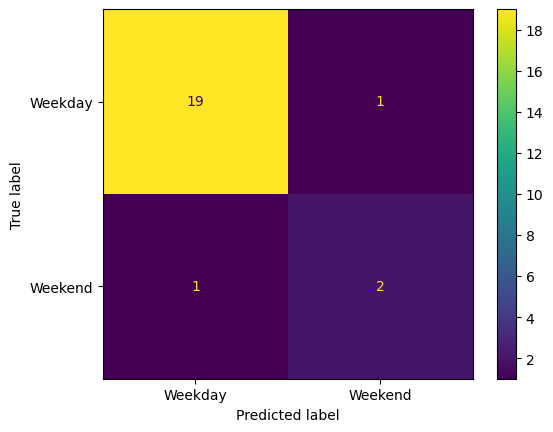

In [93]:
tree_cm = confusion_matrix(weekly_y_test,weekly_y_preds)
disp = ConfusionMatrixDisplay(tree_cm,display_labels=['Weekday','Weekend'])
disp.plot()

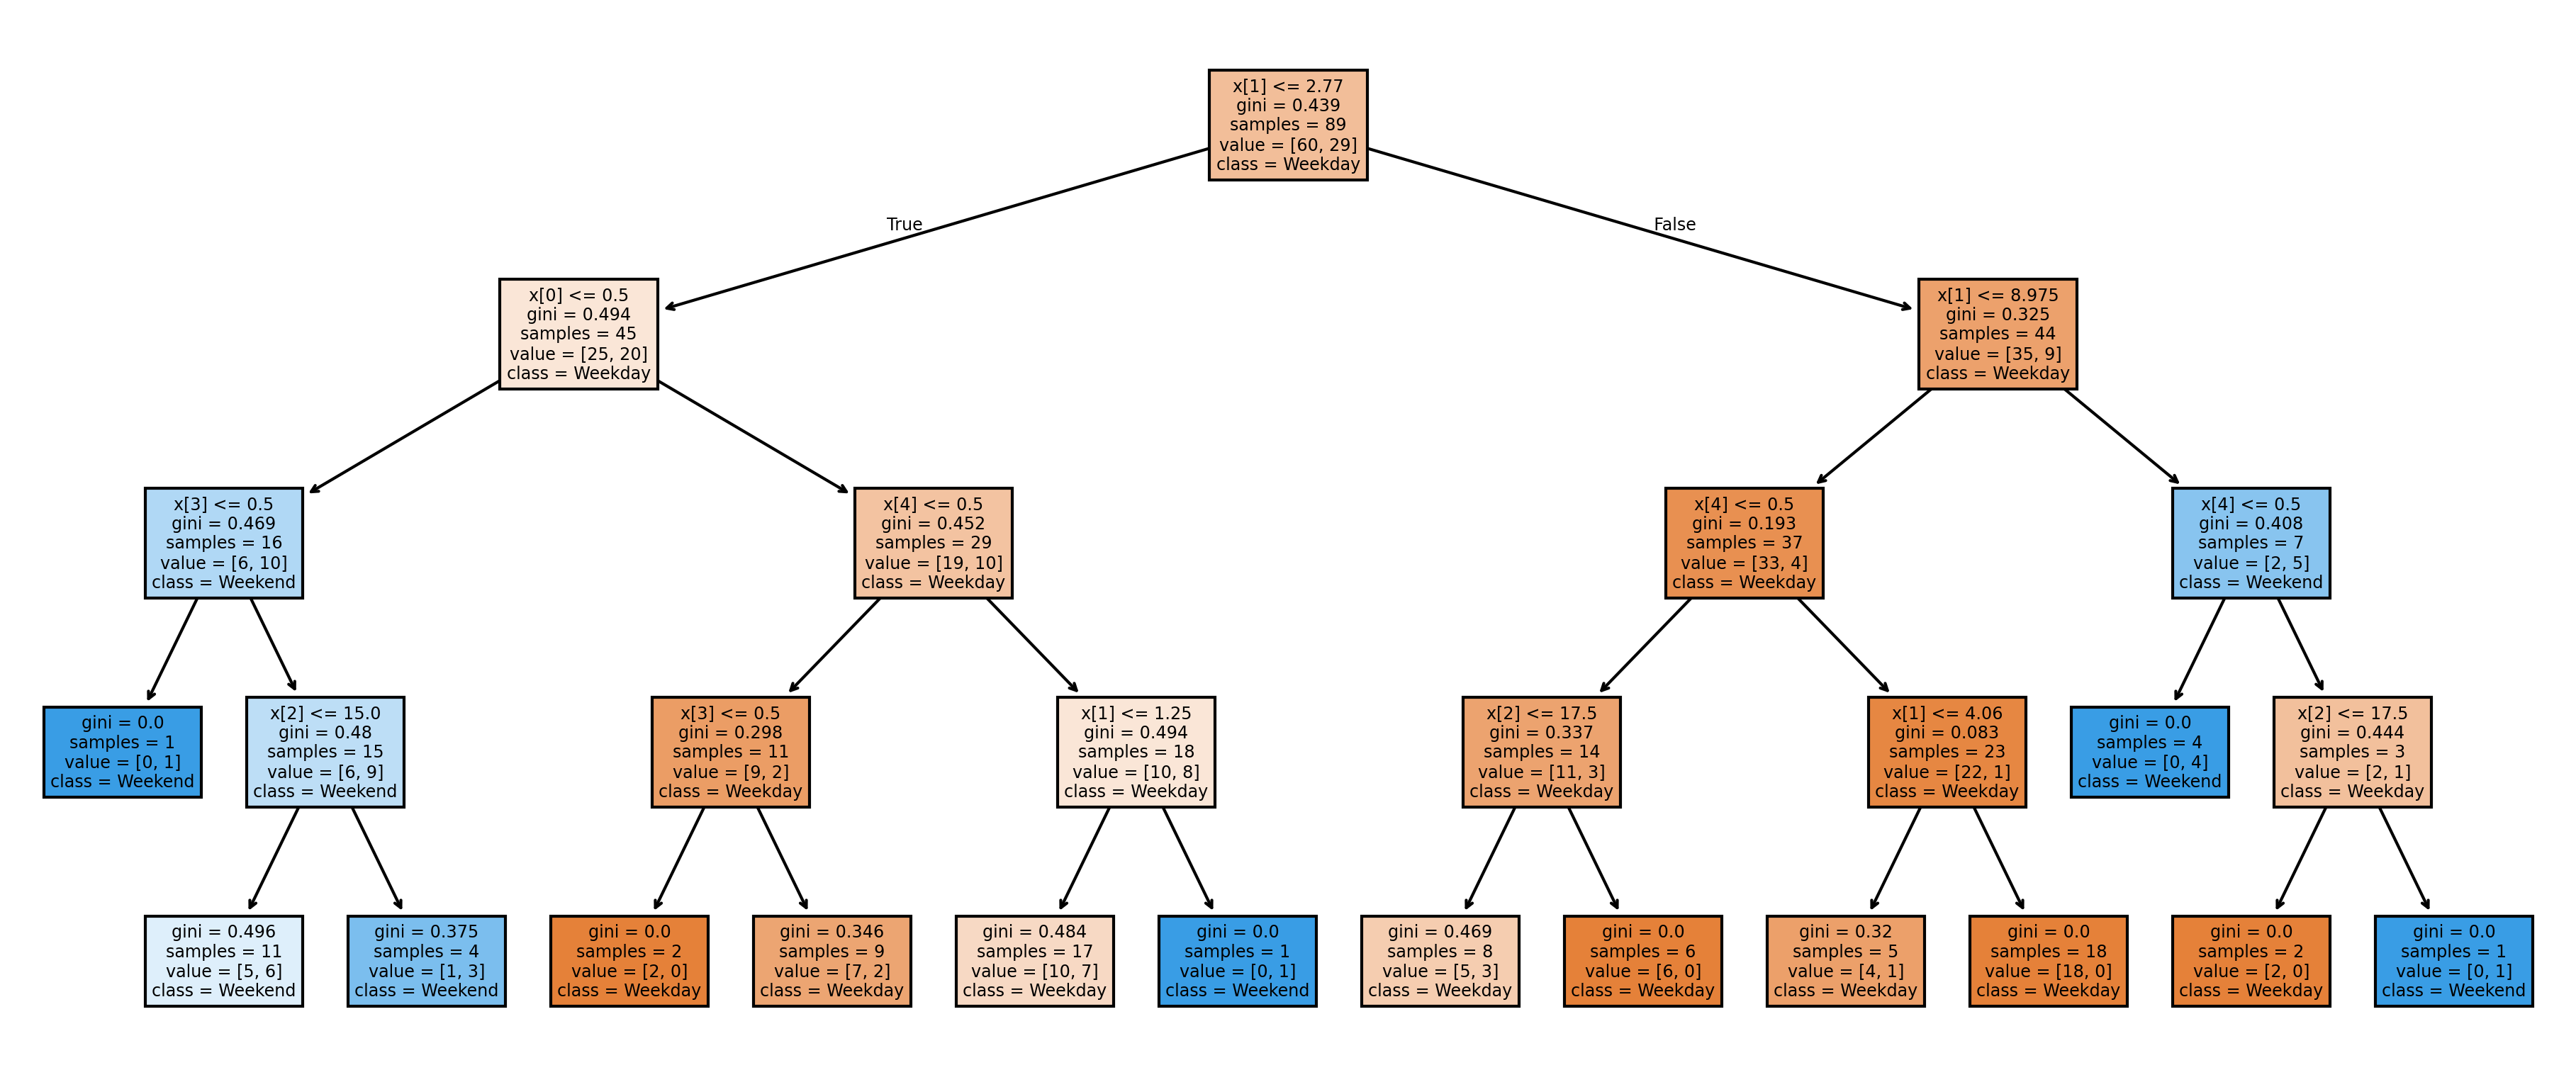

In [94]:
plt.figure(layout='constrained',dpi=300,figsize=(12,5))
plot_tree(weekly_tree,class_names=['Weekday','Weekend'],filled=True)
plt.show()

This model did not perform very well, with an average accuracy right around the baseline of $71$%. My hypothesis is that Saturdays are relatively easy to predict, but my Sunday habits are pretty similar to Monday and Friday because of my running schedule, so it confused the model.

 Let's attempt the same task with a kNN algorithm.

Model Accuracy: 0.68


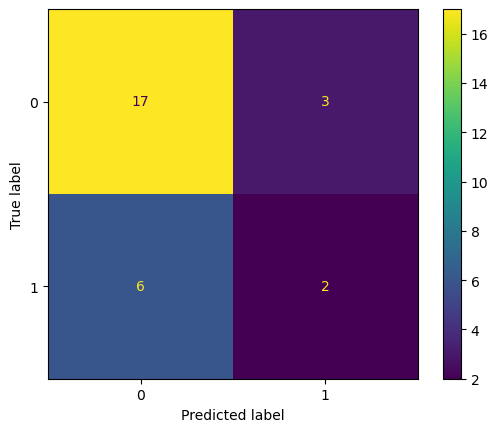

In [96]:
knn_clf, knn_y_test, knn_y_preds = utilities.knn_weekend(merged_df)
knn_cm = confusion_matrix(knn_y_test,knn_y_preds)
disp = ConfusionMatrixDisplay(knn_cm,display_labels=knn_clf.classes_)
disp.plot()

The kNN model performed better on average, with an average accuracy around $75$% - $77$%, but still not incredibly well to be considered a very strong model. Similar to the last model, I don't believe my Sunday routine was distinct enough to be able to be predicted accurately.

## Conclusion

Thus, we have completed exploratory data analysis on my New Years Resolutions. It was interesting to explore a dataset this applicable to myself, which made me more motivated to dive deeper into the project. From this exploration, I found out I have been performing well on certain goals, such as staying off Instagram and completing Duolingo lessons, while struggling with others, namely completely pushups and flossing my teeth.

My classifiers were utilized to attempt to predict the day of the week using my stats from that day. The classifiers did not have an overwhelming degree of success, which is due to small sample sizes and data inconsistencies. Since I used attributes from each row seperately, it didn't feel necessary to remove outliers for simply the machine learning task, but if we were to go deeper, removing outliers that would confuse the model would be an important step.

There are not significant ethical impacts from this project, but I'm sure my parents will be excited to see the final report. 

Overall, it has been a good experience setting and tracking long term goals and I would recommend others to do the same.

Thanks for listening!